In [67]:
from pathlib import Path
import pandas as pd
import numpy as np


DATA_DIR = Path(
    r"C:\Python\CSUREMM\test"
)


gt_diff = pd.read_csv(
    DATA_DIR / "gt_diff_panel.csv",
    parse_dates=["Time"]
).set_index("Time")


gt_logdiff = pd.read_csv(
    DATA_DIR / "gt_log_diff_panel.csv",
    parse_dates=["Time"]
).set_index("Time")


stationarity = pd.read_csv(
    DATA_DIR / "stationarity_summary.csv"
)


sp500 = pd.read_csv(
    DATA_DIR / "sp500_daily.csv",
    parse_dates=["date"]
).set_index("date")

In [73]:
def gt_eda_summary(panel):

    rows = []

    for col in panel.columns:

        x = panel[col]

        rows.append({

            "term": col,

            "observations":
                x.notna().sum(),

            "missing":
                x.isna().sum(),

            "mean":
                x.mean(),

            "std":
                x.std(),

            "min":
                x.min(),

            "max":
                x.max(),

            "zero_share":
                (x == 0).mean(),

            "unique_values":
                x.nunique(),

            "abs_change_mean":
                x.abs().mean(),

            "abs_change_std":
                x.abs().std()

        })


    return (
        pd.DataFrame(rows)
        .sort_values(
            "std",
            ascending=False
        )
    )


eda = gt_eda_summary(
    gt_logdiff
)


eda.to_csv(
    DATA_DIR / "eda_summary.csv",
    index=False
)


print(
    eda.head(20)
)

             term  observations  missing          mean       std       min  \
131      squander          1611        0  3.307927e-18  3.096515 -6.447306   
22       bequeath          1611        0 -2.713446e-03  2.981310 -6.366470   
24      betrothal          1611        0  0.000000e+00  2.429366 -6.366470   
2       affluence          1611        0  2.348328e-03  2.422803 -5.755742   
96       nobleman          1611        0  2.637816e-04  2.275759 -5.247024   
92    meritorious          1611        0  2.714677e-03  2.220432 -5.646624   
143  unprofitable          1611        0  1.102642e-18  2.099245 -6.413459   
4          afloat          1611        0  3.021581e-04  1.949352 -5.371185   
88      liquidate          1611        0  2.383895e-03  1.778331 -5.469548   
124      richness          1611        0  4.012135e-04  1.692590 -4.892019   
54      destitute          1611        0 -5.898476e-05  1.567058 -4.958944   
8    aristocratic          1611        0  2.171385e-03  1.543731

In [74]:
corr = (
    gt_logdiff
    .corr()
)


corr.to_csv(
    DATA_DIR / "corr_matrix.csv"
)


print(
    corr.iloc[:10,:10]
)

                accrue  advantage  affluence  affluent    afloat  allowance  \
accrue        1.000000   0.690533   0.270753  0.336467  0.171432   0.550716   
advantage     0.690533   1.000000   0.353016  0.502309  0.239729   0.755997   
affluence     0.270753   0.353016   1.000000  0.271722  0.159937   0.333974   
affluent      0.336467   0.502309   0.271722  1.000000  0.116125   0.456373   
afloat        0.171432   0.239729   0.159937  0.116125  1.000000   0.208211   
allowance     0.550716   0.755997   0.333974  0.456373  0.208211   1.000000   
aristocracy   0.401703   0.463856   0.235625  0.296572  0.203201   0.403888   
aristocrat    0.192176   0.288323   0.123998  0.181889  0.127261   0.260926   
aristocratic  0.188793   0.254977   0.148025  0.175292  0.055280   0.194755   
associate     0.698664   0.918880   0.356604  0.497372  0.234860   0.773968   

              aristocracy  aristocrat  aristocratic  associate  
accrue           0.401703    0.192176      0.188793   0.698664  


In [75]:
def high_corr_pairs(
    corr,
    threshold=0.8
):

    pairs=[]

    cols = corr.columns


    for i in range(len(cols)):

        for j in range(i+1,len(cols)):

            value = corr.iloc[i,j]

            if abs(value) >= threshold:

                pairs.append({

                    "term1":cols[i],

                    "term2":cols[j],

                    "correlation":value

                })


    return (
        pd.DataFrame(pairs)
        .sort_values(
            "correlation",
            key=lambda x:x.abs(),
            ascending=False
        )
    )


corr_pairs = high_corr_pairs(
    corr,
    0.8
)


corr_pairs.to_csv(
    DATA_DIR / "corr_high_pairs.csv",
    index=False
)


print(
    corr_pairs.head(20)
)

            term1         term2  correlation
208    contribute    successful     0.942629
155     community   cooperative     0.935522
34      associate     community     0.932570
6       advantage     community     0.932538
182  compensation   partnership     0.932338
163     community   partnership     0.930445
251       default   partnership     0.930026
46      associate   partnership     0.928346
229   cooperative   partnership     0.925440
35      associate  compensation     0.923936
174  compensation   cooperative     0.922704
152     community  compensation     0.922377
30      associate   beneficiary     0.921875
178  compensation        equity     0.921644
76    beneficiary     community     0.918984
154     community  contribution     0.918883
0       advantage     associate     0.918880
213  contribution       expense     0.917737
38      associate   cooperative     0.914800
97        benefit    contribute     0.914756


In [82]:
target = sp500["sp500_rv5"]


aligned = pd.concat(
    [
        gt_logdiff,
        target
    ],
    axis=1
).dropna()


target_corr = (
    aligned
    .corr()["sp500_rv5"]
    .drop("sp500_rv5")
    .sort_values(
        key=lambda x:x.abs(),
        ascending=False
    )
)


target_corr.to_csv(
    DATA_DIR / "corr_gt_sp500.csv"
)


print(
    target_corr.head(20)
)

subsidy        -0.067264
liquidation    -0.051986
blackmail      -0.048132
bankrupt       -0.046344
ruin           -0.044060
debtor         -0.044018
allowance      -0.043114
depreciation   -0.042429
donation       -0.041676
owe            -0.040690
charity        -0.040429
luxury         -0.038430
warfare         0.038082
rich           -0.037197
tariff         -0.036648
expense        -0.034926
benevolent     -0.034311
charitable     -0.033746
subsidize      -0.033501
laid           -0.032702
Name: sp500_rv5, dtype: float64


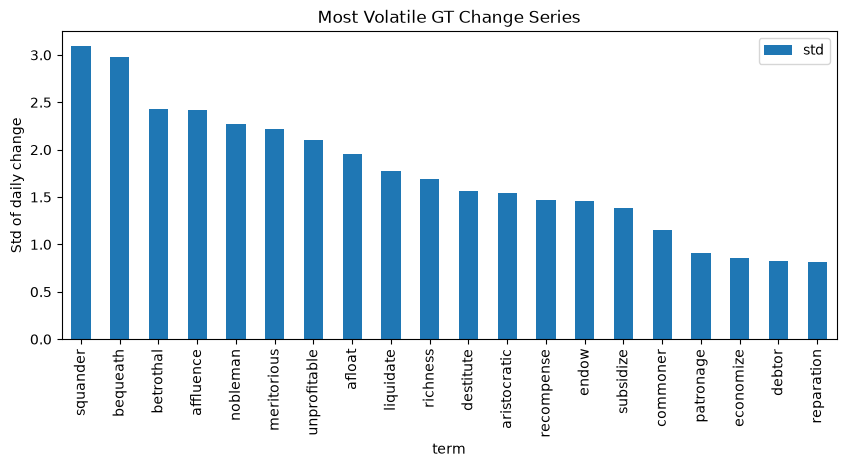

In [77]:
import matplotlib.pyplot as plt

eda.head(20).plot(
    x="term",
    y="std",
    kind="bar",
    figsize=(10,4),
    title="Most Volatile GT Change Series"
)

plt.ylabel(
    "Std of daily change"
)

plt.show()